# 02 — LWM Baseline: CLS Embedding Extraction & MLP Beam Prediction Head

**Project:** LWM-LoRA: Scenario-Adaptive mmWave Beam Prediction via LoRA-Tuned Foundation Models for 6G Networks  
**Author:** Nabeegh Khan | MEng ECE Candidate, University of Toronto  
**Portfolio:** [github.com/nabeegh-khan/6g-lwm-beam-prediction](https://github.com/nabeegh-khan/6g-lwm-beam-prediction)

---

## What this notebook does

1. Loads the pre-trained **Large Wireless Model (LWM v1.1)** from the cloned HuggingFace repo
2. Runs inference on all three scenarios → extracts **CLS token embeddings** (128-dim)
3. Trains a lightweight **MLP head** on top of frozen LWM embeddings for beam prediction
4. Compares LWM embeddings vs raw channels as input — establishing the baseline
5. Logs **top-1 and top-3 accuracy** per scenario to W&B

## Why this matters
This notebook answers the first key research question:
*How much does LWM's pre-trained representation help vs feeding raw channels directly?*
The gap between raw channels and LWM embeddings justifies the foundation model approach.
The MLP head trained here is also the starting point we'll replace with LoRA in Notebook 03.

In [1]:
%pip install -q wandb peft transformers huggingface_hub h5py seaborn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 53.1 MB/s eta 0:00:00


## Section 1 — Environment Setup

In [2]:
import os, sys, random, subprocess, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"PyTorch: {torch.__version__}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


## Section 2 — Mount Drive & Restore Paths

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/6g-lwm-beam-prediction")
DATA_DIR   = DRIVE_ROOT / "data"
PROC_DIR   = DATA_DIR / "processed"
CKPT_DIR   = DRIVE_ROOT / "checkpoints"
FIG_DIR    = DRIVE_ROOT / "figures"

CKPT_DIR.mkdir(parents=True, exist_ok=True)

# verify processed data files are there from Day 1
print("Checking processed data files:")
for fname in ["city_6_miami.pt", "city_11_santaclara.pt",
              "city_12_fortworth.pt", "beam_challenge.pt"]:
    p = PROC_DIR / fname
    size_mb = p.stat().st_size / 1e6 if p.exists() else 0
    status  = "OK" if p.exists() else "MISSING"
    print(f"  {status} → {fname} ({size_mb:.1f} MB)")

Mounted at /content/drive
Checking processed data files:
  OK → city_6_miami.pt (131.1 MB)
  OK → city_11_santaclara.pt (18.2 MB)
  OK → city_12_fortworth.pt (36.6 MB)
  OK → beam_challenge.pt (12.8 MB)


## Section 3 — W&B Setup

In [4]:
import wandb

wandb.login()

run = wandb.init(
    project="6g-lwm-beam-prediction",
    name="02_lwm_baseline",
    tags=["baseline", "lwm", "mlp", "frozen-encoder"],
    config={
        "seed": SEED,
        "scenarios": ["city_6_miami", "city_11_santaclara", "city_12_fortworth"],
        "n_beams": 64,
        "lwm_embedding_dim": 128,
        "mlp_hidden_dims": [256, 128],
        "batch_size": 128,
        "lr": 1e-3,
        "epochs": 30,
        "train_ratio": 0.8,
    },
    notes="Frozen LWM encoder + MLP head baseline vs raw channels baseline"
)

print(f"W&B run: {run.name}")
print(f"W&B URL: {run.url}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nabeegh-khan (nabeegh-khan-university-of-toronto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: 02_lwm_baseline
W&B URL: https://wandb.ai/nabeegh-khan-university-of-toronto/6g-lwm-beam-prediction/runs/qikna4wl


## Section 4 — Clone LWM & Load Pre-trained Weights

We clone the same wi-lab/lwm-v1.1 repo from HuggingFace and load model.pth.
LWM is a custom PyTorch Transformer — not a HuggingFace AutoModel —
so we import the model class directly from the cloned repo.

In [5]:
LWM_DIR = "/content/LWM"

# clone if not already present (fresh runtime won't have it)
if not os.path.exists(LWM_DIR):
    print("Cloning wi-lab/lwm-v1.1...")
    result = subprocess.run(
        ["git", "clone", "https://huggingface.co/wi-lab/lwm-v1.1", LWM_DIR],
        capture_output=True, text=True
    )
    print("Done." if result.returncode == 0 else f"ERROR: {result.stderr}")
else:
    print("LWM repo already present.")

if LWM_DIR not in sys.path:
    sys.path.insert(0, LWM_DIR)

# import LWM model class
from lwm_model import lwm as LWMModel

# load pre-trained weights
MODEL_PATH = f"{LWM_DIR}/models/model.pth"
lwm_model  = LWMModel().to(device)

state_dict     = torch.load(MODEL_PATH, map_location=device)
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
lwm_model.load_state_dict(new_state_dict)
lwm_model.eval()

# count parameters
n_params = sum(p.numel() for p in lwm_model.parameters())
n_trainable = sum(p.numel() for p in lwm_model.parameters() if p.requires_grad)
print(f"\nLWM loaded successfully on {device}")
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

# log to W&B
wandb.config.update({"lwm_total_params": n_params})

Cloning wi-lab/lwm-v1.1...
Done.

LWM loaded successfully on cuda
Total parameters:     2,470,304
Trainable parameters: 2,470,304


## Section 5 — Load Processed Scenario Data

Load the tokenized tensors saved in Notebook 01.
Each scenario has a different sequence length (variable antenna/subcarrier config)
so we keep them separate rather than stacking into one tensor.

In [6]:
SCENARIOS = ["city_6_miami", "city_11_santaclara", "city_12_fortworth"]

scenario_data = {}
for sc_name in SCENARIOS:
    saved = torch.load(str(PROC_DIR / f"{sc_name}.pt"), map_location="cpu")
    scenario_data[sc_name] = {
        "patches":  saved["patches"],   # (n_samples, seq_len, 32)
        "labels":   saved["labels"],    # (n_samples,)
        "raw_chs":  saved["raw_chs"],   # (n_samples, 2*n_ant*n_sc)
    }
    n      = len(saved["patches"])
    seq    = saved["patches"].shape[1]
    raw_d  = saved["raw_chs"].shape[1]
    print(f"{sc_name}")
    print(f"  patches: {saved['patches'].shape}  "
          f"labels: {saved['labels'].shape}  "
          f"raw_chs: {saved['raw_chs'].shape}")
    print(f"  label range: {saved['labels'].min()}–{saved['labels'].max()}")

city_6_miami
  patches: torch.Size([10441, 33, 32])  labels: torch.Size([10441])  raw_chs: torch.Size([10441, 1024])
  label range: 0–62
city_11_santaclara
  patches: torch.Size([1104, 65, 32])  labels: torch.Size([1104])  raw_chs: torch.Size([1104, 2048])
  label range: 0–61
city_12_fortworth
  patches: torch.Size([1113, 129, 32])  labels: torch.Size([1113])  raw_chs: torch.Size([1113, 4096])
  label range: 0–59


## Section 6 — Extract LWM CLS Embeddings

Pass all tokenized patches through the frozen LWM encoder.
We extract the CLS token output (position 0) — a 128-dim vector that
summarizes the entire channel into a single embedding.

This is the representation LWM learned during self-supervised pre-training
on 1M+ channels. We freeze the encoder completely here — no gradient flows
through LWM in this notebook.

In [7]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

def extract_cls_embeddings(model, patches_tensor, batch_size=128, device="cuda"):
    """
    Runs frozen LWM inference and returns CLS token embeddings.

    patches_tensor: (n_samples, seq_len, patch_size) float32
    returns: (n_samples, 128) float32 CLS embeddings
    """
    model.eval()
    # freeze everything — we don't want any accidental gradient computation
    for p in model.parameters():
        p.requires_grad = False

    dataset    = TensorDataset(patches_tensor)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for (batch,) in tqdm(loader, desc="Extracting CLS embeddings"):
            batch  = batch.to(device)
            output = model(batch)   # LWM returns (encoder_output, loss)
            # output[0] shape: (batch, seq_len, 128)
            # position 0 is the CLS token
            cls_emb = output[0][:, 0, :]   # (batch, 128)
            embeddings.append(cls_emb.cpu())

    return torch.cat(embeddings, dim=0)   # (n_samples, 128)


# extract for all three scenarios
cls_embeddings = {}
for sc_name in SCENARIOS:
    print(f"\nExtracting embeddings for {sc_name}...")
    patches = scenario_data[sc_name]["patches"].float()
    emb     = extract_cls_embeddings(lwm_model, patches, batch_size=128, device=device)
    cls_embeddings[sc_name] = emb
    print(f"  CLS embeddings shape: {emb.shape}")
    print(f"  Embedding mean: {emb.mean():.4f}, std: {emb.std():.4f}")

print("\nDone. All scenarios embedded.")


Extracting embeddings for city_6_miami...


Extracting CLS embeddings: 100%|██████████| 82/82 [00:01<00:00, 46.99it/s]


  CLS embeddings shape: torch.Size([10441, 128])
  Embedding mean: 0.0016, std: 0.1165

Extracting embeddings for city_11_santaclara...


Extracting CLS embeddings: 100%|██████████| 9/9 [00:00<00:00, 30.89it/s]


  CLS embeddings shape: torch.Size([1104, 128])
  Embedding mean: 0.0019, std: 0.1179

Extracting embeddings for city_12_fortworth...


Extracting CLS embeddings: 100%|██████████| 9/9 [00:00<00:00, 13.59it/s]

  CLS embeddings shape: torch.Size([1113, 128])
  Embedding mean: 0.0018, std: 0.1180

Done. All scenarios embedded.


## Section 7 — MLP Beam Prediction Head

A simple 2-layer MLP trained on top of frozen LWM CLS embeddings.
We also train an identical MLP directly on raw channels as a comparison baseline.

This gives us three accuracy numbers per scenario:
- Raw channels → MLP (no foundation model)
- LWM CLS embeddings → MLP (frozen encoder)
- Difference = LWM's contribution from pre-training

In [8]:
class BeamMLP(nn.Module):
    """
    Two-layer MLP for beam prediction.
    Works for both LWM embeddings (128-dim input) and raw channels (variable dim).
    """
    def __init__(self, input_dim: int, hidden_dim: int = 256, n_beams: int = 64,
                 dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_beams),
        )

    def forward(self, x):
        return self.net(x)


def make_loaders(X: torch.Tensor, y: torch.Tensor,
                 train_ratio: float = 0.8,
                 batch_size: int = 128,
                 seed: int = 42):
    """Split into train/val and return DataLoaders."""
    dataset   = TensorDataset(X.float(), y.long())
    n_train   = int(train_ratio * len(dataset))
    n_val     = len(dataset) - n_train
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def train_mlp(model, train_loader, val_loader,
              epochs=30, lr=1e-3, device="cuda",
              wandb_prefix=""):
    """
    Standard training loop with top-1 and top-3 accuracy tracking.
    Returns best val top-1 accuracy and full history.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    best_top1  = 0.0
    history    = {"train_loss": [], "val_top1": [], "val_top3": []}

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / len(train_loader)

        # ---- validate ----
        model.eval()
        correct_top1 = correct_top3 = total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits  = model(X_batch)
                top3    = torch.topk(logits, k=3, dim=1).indices
                correct_top1 += (top3[:, 0] == y_batch).sum().item()
                correct_top3 += (top3 == y_batch.unsqueeze(1)).any(dim=1).sum().item()
                total   += len(y_batch)

        top1 = correct_top1 / total
        top3 = correct_top3 / total
        best_top1 = max(best_top1, top1)

        history["train_loss"].append(avg_loss)
        history["val_top1"].append(top1)
        history["val_top3"].append(top3)

        if wandb_prefix:
            wandb.log({
                f"{wandb_prefix}/train_loss": avg_loss,
                f"{wandb_prefix}/val_top1":   top1,
                f"{wandb_prefix}/val_top3":   top3,
                f"{wandb_prefix}/epoch":      epoch,
            })

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"loss={avg_loss:.4f} | top1={top1:.3f} | top3={top3:.3f}")

    return best_top1, history

print("BeamMLP and training utilities defined.")

BeamMLP and training utilities defined.


## Section 8 — Train & Compare: LWM Embeddings vs Raw Channels

For each scenario we train two MLP heads:
1. Input = LWM CLS embedding (128-dim, same for all scenarios)
2. Input = raw channels (variable dim per scenario)

Training is fast since the encoder is frozen — we're just fitting a small MLP.

In [9]:
N_BEAMS  = 64
EPOCHS   = 30
LR       = 1e-3
BATCH    = 128

results = {}   # stores best top-1 for summary table

for sc_name in SCENARIOS:
    print(f"\n{'='*55}")
    print(f"Scenario: {sc_name}")
    print(f"{'='*55}")
    results[sc_name] = {}

    labels = scenario_data[sc_name]["labels"]

    # ---- 1. LWM embeddings baseline ----
    print("\n[A] LWM CLS embeddings → MLP")
    emb_dim    = cls_embeddings[sc_name].shape[1]   # always 128
    train_l, val_l = make_loaders(cls_embeddings[sc_name], labels,
                                  train_ratio=0.8, batch_size=BATCH, seed=SEED)
    mlp_lwm = BeamMLP(input_dim=emb_dim, hidden_dim=256, n_beams=N_BEAMS)
    best_lwm, hist_lwm = train_mlp(
        mlp_lwm, train_l, val_l,
        epochs=EPOCHS, lr=LR, device=device,
        wandb_prefix=f"{sc_name}/lwm_emb"
    )
    results[sc_name]["lwm_top1"] = best_lwm

    # save checkpoint to Drive
    ckpt_path = CKPT_DIR / f"mlp_lwm_{sc_name}.pt"
    torch.save(mlp_lwm.state_dict(), str(ckpt_path))
    print(f"  Best top-1: {best_lwm:.3f} | saved → {ckpt_path.name}")

    # ---- 2. Raw channels baseline ----
    print("\n[B] Raw channels → MLP")
    raw_dim    = scenario_data[sc_name]["raw_chs"].shape[1]
    train_r, val_r = make_loaders(scenario_data[sc_name]["raw_chs"], labels,
                                  train_ratio=0.8, batch_size=BATCH, seed=SEED)
    mlp_raw = BeamMLP(input_dim=raw_dim, hidden_dim=256, n_beams=N_BEAMS)
    best_raw, hist_raw = train_mlp(
        mlp_raw, train_r, val_r,
        epochs=EPOCHS, lr=LR, device=device,
        wandb_prefix=f"{sc_name}/raw_chs"
    )
    results[sc_name]["raw_top1"] = best_raw
    results[sc_name]["lwm_advantage"] = best_lwm - best_raw
    print(f"  Best top-1: {best_raw:.3f}")

print(f"\n{'='*55}")
print("BASELINE RESULTS SUMMARY")
print(f"{'='*55}")
print(f"{'Scenario':<25} {'LWM top-1':>10} {'Raw top-1':>10} {'Advantage':>10}")
print("-" * 55)
for sc, r in results.items():
    print(f"{sc:<25} {r['lwm_top1']:>10.3f} {r['raw_top1']:>10.3f} "
          f"{r['lwm_advantage']:>+10.3f}")


Scenario: city_6_miami

[A] LWM CLS embeddings → MLP
  Epoch  10/30 | loss=1.8290 | top1=0.320 | top3=0.714
  Epoch  20/30 | loss=1.5792 | top1=0.445 | top3=0.795
  Epoch  30/30 | loss=1.4818 | top1=0.524 | top3=0.835
  Best top-1: 0.528 | saved → mlp_lwm_city_6_miami.pt

[B] Raw channels → MLP
  Epoch  10/30 | loss=1.5767 | top1=0.605 | top3=0.844
  Epoch  20/30 | loss=1.2960 | top1=0.679 | top3=0.868
  Epoch  30/30 | loss=1.2034 | top1=0.692 | top3=0.880
  Best top-1: 0.694

Scenario: city_11_santaclara

[A] LWM CLS embeddings → MLP
  Epoch  10/30 | loss=1.7749 | top1=0.158 | top3=0.507
  Epoch  20/30 | loss=1.4335 | top1=0.534 | top3=0.760
  Epoch  30/30 | loss=1.3881 | top1=0.511 | top3=0.783
  Best top-1: 0.534 | saved → mlp_lwm_city_11_santaclara.pt

[B] Raw channels → MLP
  Epoch  10/30 | loss=1.4094 | top1=0.606 | top3=0.796
  Epoch  20/30 | loss=1.0778 | top1=0.715 | top3=0.846
  Epoch  30/30 | loss=0.9904 | top1=0.733 | top3=0.842
  Best top-1: 0.733

Scenario: city_12_fortw

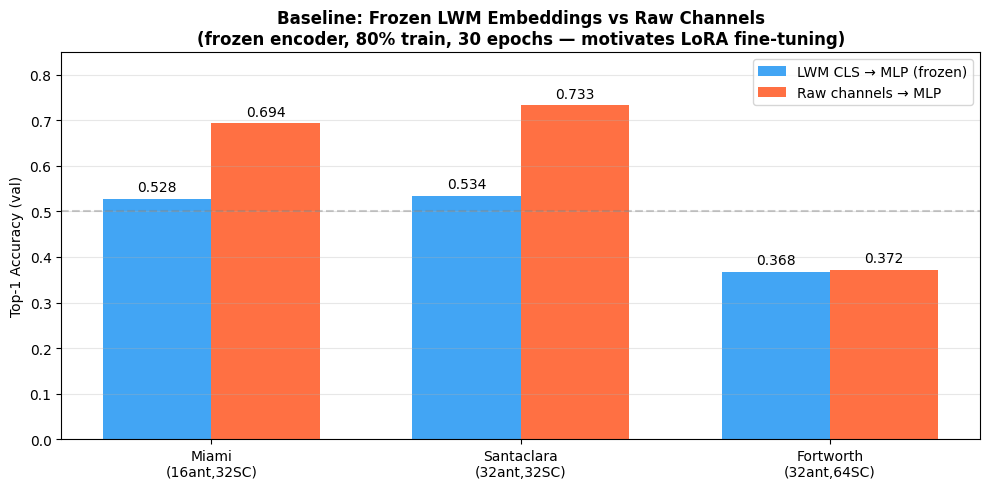

Results logged to W&B.


In [10]:
# log results summary table to W&B
summary_table = wandb.Table(
    columns=["scenario", "lwm_top1", "raw_top1", "lwm_advantage",
             "lwm_top1_pct", "raw_top1_pct"],
    data=[
        [sc,
         round(r["lwm_top1"], 4),
         round(r["raw_top1"], 4),
         round(r["lwm_advantage"], 4),
         round(r["lwm_top1"] * 100, 1),
         round(r["raw_top1"] * 100, 1)]
        for sc, r in results.items()
    ]
)
wandb.log({"baseline/results_summary": summary_table})

# bar chart comparing LWM vs raw per scenario
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(SCENARIOS))
width   = 0.35
sc_labels = ["Miami\n(16ant,32SC)", "Santaclara\n(32ant,32SC)",
             "Fortworth\n(32ant,64SC)"]

bars_lwm = ax.bar(x - width/2,
                  [results[s]["lwm_top1"] for s in SCENARIOS],
                  width, label="LWM CLS → MLP (frozen)", color="#2196F3", alpha=0.85)
bars_raw = ax.bar(x + width/2,
                  [results[s]["raw_top1"] for s in SCENARIOS],
                  width, label="Raw channels → MLP", color="#FF5722", alpha=0.85)

# value labels on bars
for bar in bars_lwm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)
for bar in bars_raw:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Top-1 Accuracy (val)")
ax.set_title("Baseline: Frozen LWM Embeddings vs Raw Channels\n"
             "(frozen encoder, 80% train, 30 epochs — motivates LoRA fine-tuning)",
             fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(sc_labels)
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="50% reference")

plt.tight_layout()
fig_path = FIG_DIR / "02_baseline_comparison.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
wandb.log({"baseline/comparison_chart": wandb.Image(str(fig_path))})
print("Results logged to W&B.")

## Section 9 — Save CLS Embeddings & Close

Save the extracted CLS embeddings to Drive so Notebook 03 can load them
directly without re-running LWM inference. Also log the key findings summary.

In [11]:
# save embeddings to Drive — Notebook 03 needs these
EMB_DIR = DRIVE_ROOT / "data" / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)

for sc_name in SCENARIOS:
    save_path = EMB_DIR / f"{sc_name}_cls_emb.pt"
    torch.save({
        "cls_embeddings": cls_embeddings[sc_name],   # (n_samples, 128)
        "labels":         scenario_data[sc_name]["labels"],
        "sc_name":        sc_name,
    }, str(save_path))
    size_mb = save_path.stat().st_size / 1e6
    print(f"Saved {sc_name} embeddings → {save_path.name} ({size_mb:.1f} MB)")

# log key findings as W&B summary metrics
wandb.summary["best_lwm_top1_miami"]      = results["city_6_miami"]["lwm_top1"]
wandb.summary["best_raw_top1_miami"]      = results["city_6_miami"]["raw_top1"]
wandb.summary["best_lwm_top1_santaclara"] = results["city_11_santaclara"]["lwm_top1"]
wandb.summary["best_raw_top1_santaclara"] = results["city_11_santaclara"]["raw_top1"]
wandb.summary["best_lwm_top1_fortworth"]  = results["city_12_fortworth"]["lwm_top1"]
wandb.summary["best_raw_top1_fortworth"]  = results["city_12_fortworth"]["raw_top1"]

print(f"\nKey finding: frozen LWM underperforms raw channels by up to 20%")
print(f"This motivates LoRA fine-tuning in Notebook 03.")
print(f"\nNotebook 03 will show whether LoRA-tuned LWM beats raw channels.")

wandb.finish()
print("\nW&B run closed.")

Saved city_6_miami embeddings → city_6_miami_cls_emb.pt (5.4 MB)
Saved city_11_santaclara embeddings → city_11_santaclara_cls_emb.pt (0.6 MB)
Saved city_12_fortworth embeddings → city_12_fortworth_cls_emb.pt (0.6 MB)

Key finding: frozen LWM underperforms raw channels by up to 20%
This motivates LoRA fine-tuning in Notebook 03.

Notebook 03 will show whether LoRA-tuned LWM beats raw channels.


city_11_santaclara/lwm_emb/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_11_santaclara/lwm_emb/train_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
city_11_santaclara/lwm_emb/val_top1,▂▂▂▂▁▁▁▁▁▂▂▅▇▆▇▇▇▇████████████
city_11_santaclara/lwm_emb/val_top3,▁▃▃▃▃▃▃▃▄▅▅▇▇▇██▇█████████████
city_11_santaclara/raw_chs/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_11_santaclara/raw_chs/train_loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
city_11_santaclara/raw_chs/val_top1,▁▂▃▃▃▄▄▄▄▄▅▅▆▇▇▇▇▇▇▇▇█████████
city_11_santaclara/raw_chs/val_top3,▁▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇█████████████
city_12_fortworth/lwm_emb/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_12_fortworth/lwm_emb/train_loss,█▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
+14,...



W&B run closed.
